In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = load_iris()
iris = pd.DataFrame(data.data, columns=['sepal_length', 'sepal_width', 'petal_length', 'petal_width'])
iris['species'] = pd.Categorical.from_codes(data.target, data.target_names)

print("Dataset loaded successfully!")
print("Shape:", iris.shape)

Dataset loaded successfully!
Shape: (150, 5)


In [3]:
print("Shape of dataset:", iris.shape)
print("\nColumn names:", iris.columns.tolist())
print("\nFirst 5 rows:")
iris.head()

Shape of dataset: (150, 5)

Column names: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']

First 5 rows:


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [4]:
print("Basic Statistical Summary:")
display(iris.describe())

print("\nData Types:\n", iris.dtypes)
print("\nMissing Values:\n", iris.isnull().sum())
print("\nSpecies Count:")
print(iris['species'].value_counts())

Basic Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Data Types:
 sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object

Missing Values:
 sepal_length    0
sepal_width     0
petal_length    0
petal_width     0
species         0
dtype: int64

Species Count:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


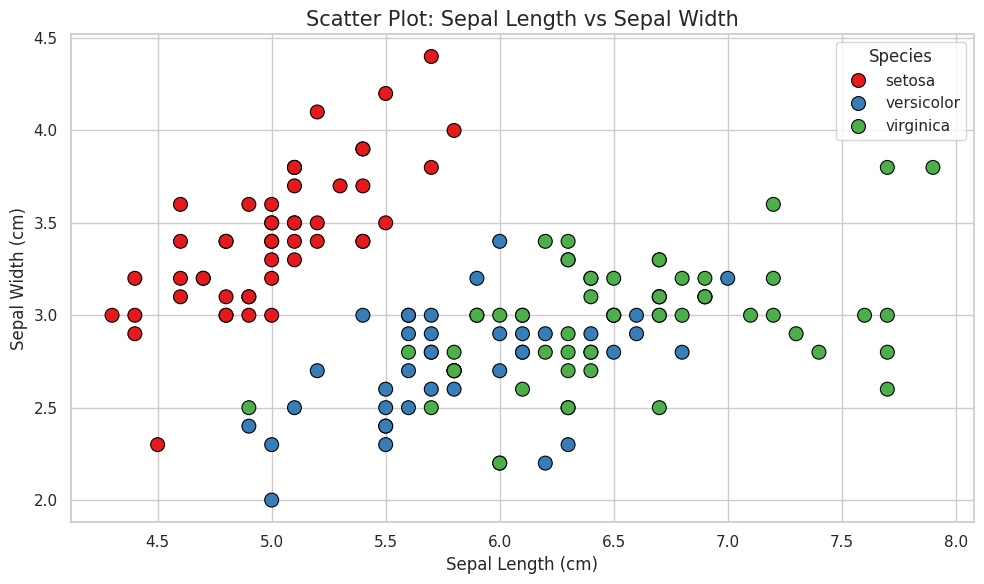

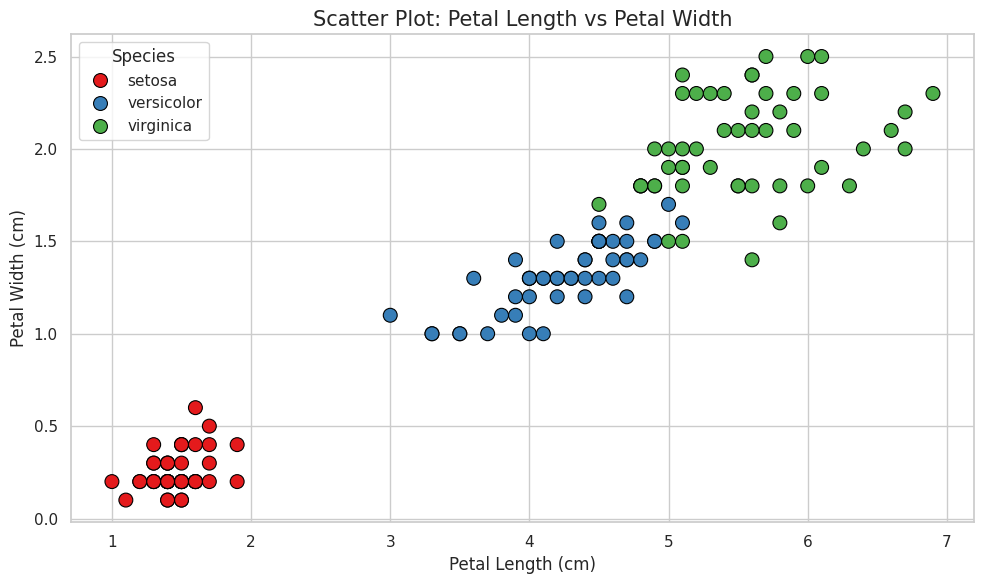

In [5]:
# Scatter Plot 1: Sepal Length vs Sepal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris, x='sepal_length', y='sepal_width',
                hue='species', palette='Set1', s=100, edgecolor='black')
plt.title('Scatter Plot: Sepal Length vs Sepal Width', fontsize=15)
plt.xlabel('Sepal Length (cm)')
plt.ylabel('Sepal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

# Scatter Plot 2: Petal Length vs Petal Width
plt.figure(figsize=(10, 6))
sns.scatterplot(data=iris, x='petal_length', y='petal_width',
                hue='species', palette='Set1', s=100, edgecolor='black')
plt.title('Scatter Plot: Petal Length vs Petal Width', fontsize=15)
plt.xlabel('Petal Length (cm)')
plt.ylabel('Petal Width (cm)')
plt.legend(title='Species')
plt.tight_layout()
plt.show()

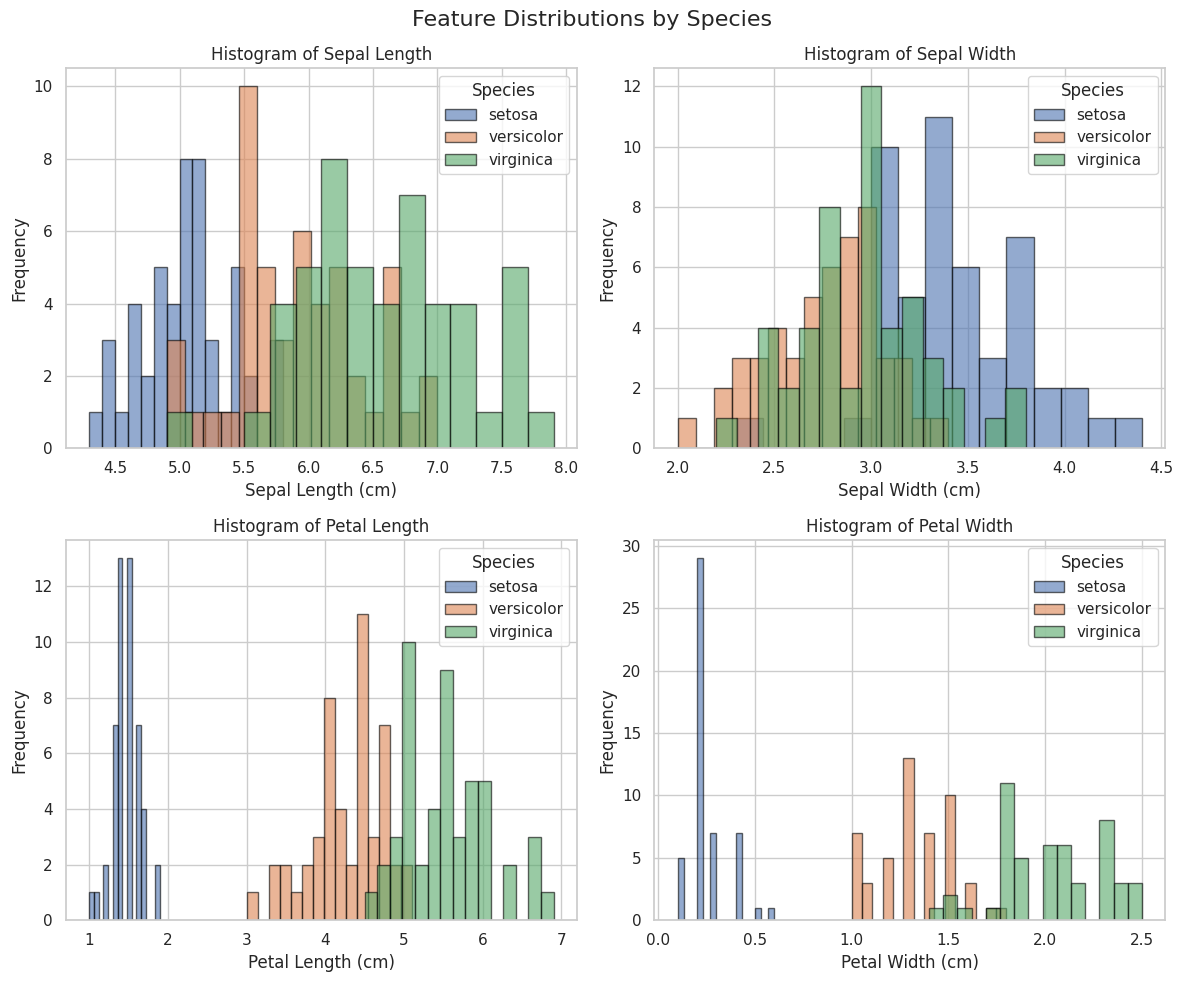

In [6]:
features = ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    for species in iris['species'].unique():
        subset = iris[iris['species'] == species]
        ax.hist(subset[feature], bins=15, alpha=0.6, label=species, edgecolor='black')
    ax.set_title(f'Histogram of {feature.replace("_", " ").title()}', fontsize=12)
    ax.set_xlabel(feature.replace("_", " ").title() + ' (cm)')
    ax.set_ylabel('Frequency')
    ax.legend(title='Species')

plt.suptitle('Feature Distributions by Species', fontsize=16)
plt.tight_layout()
plt.show()

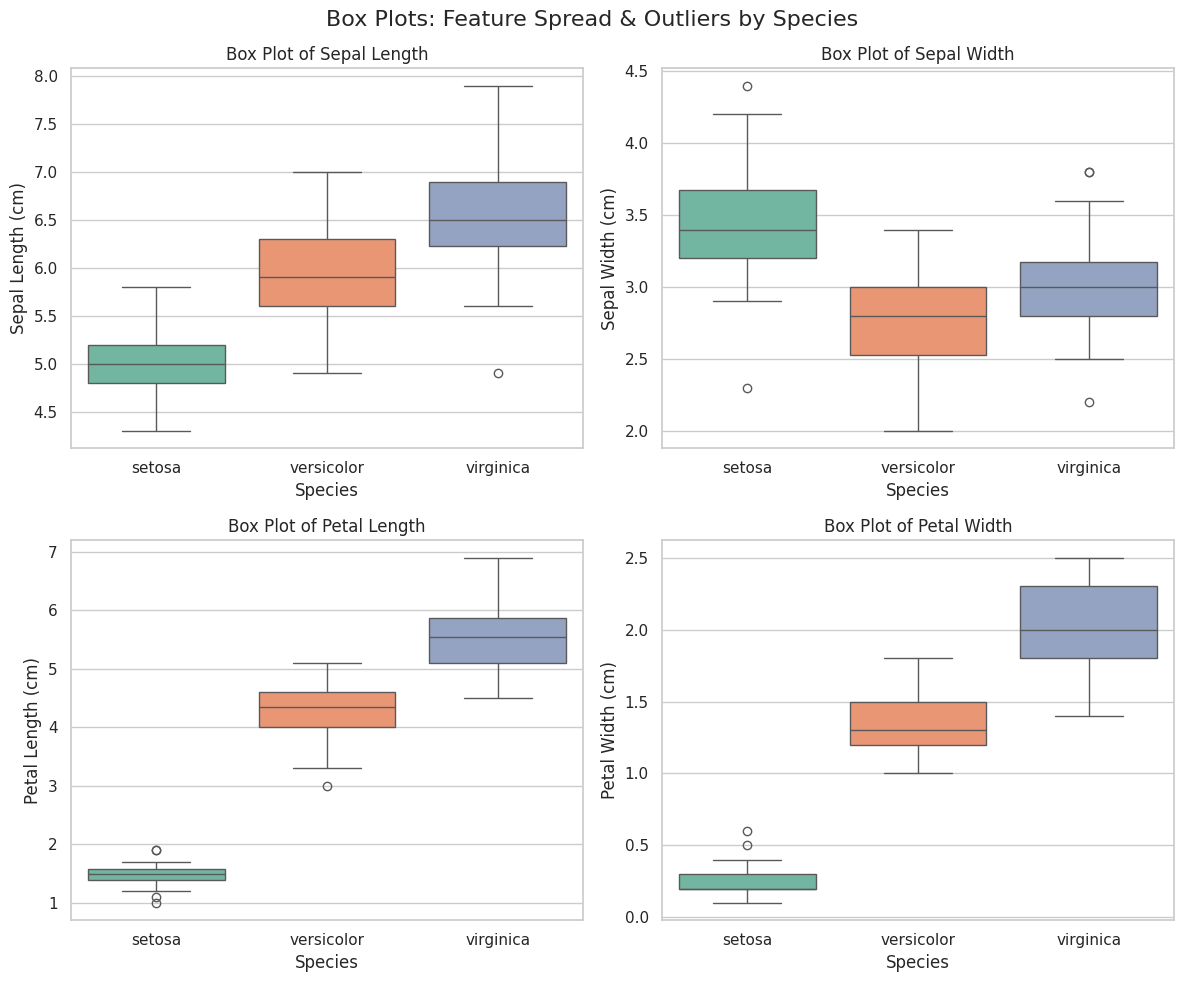

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

for i, feature in enumerate(features):
    ax = axes[i // 2][i % 2]
    sns.boxplot(data=iris, x='species', y=feature, 
                hue='species', palette='Set2', legend=False, ax=ax)
    ax.set_title(f'Box Plot of {feature.replace("_", " ").title()}', fontsize=12)
    ax.set_xlabel('Species')
    ax.set_ylabel(feature.replace("_", " ").title() + ' (cm)')

plt.suptitle('Box Plots: Feature Spread & Outliers by Species', fontsize=16)
plt.tight_layout()
plt.show()

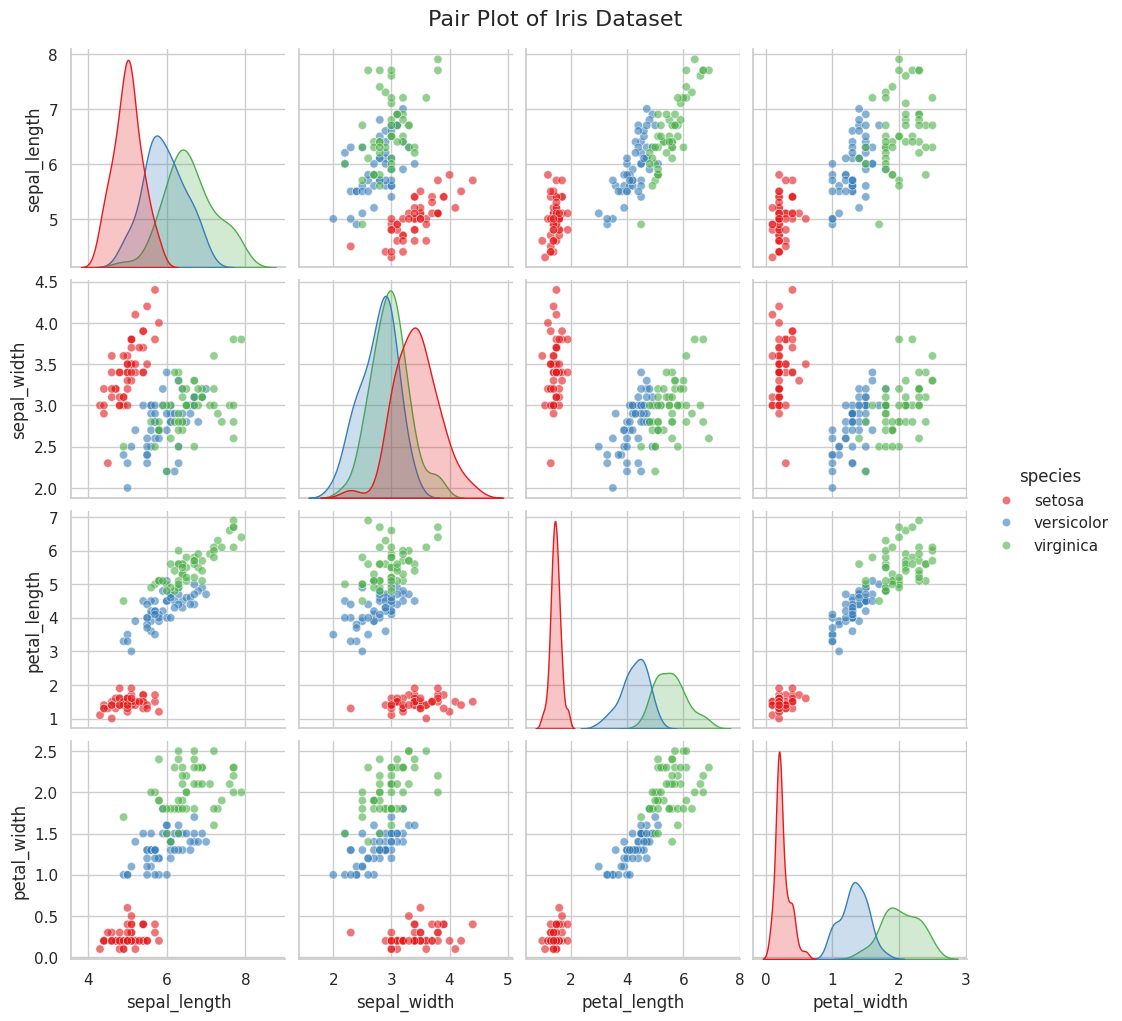

In [8]:
sns.pairplot(iris, hue='species', palette='Set1', diag_kind='kde', plot_kws={'alpha': 0.6})
plt.suptitle('Pair Plot of Iris Dataset', y=1.02, fontsize=16)
plt.show()

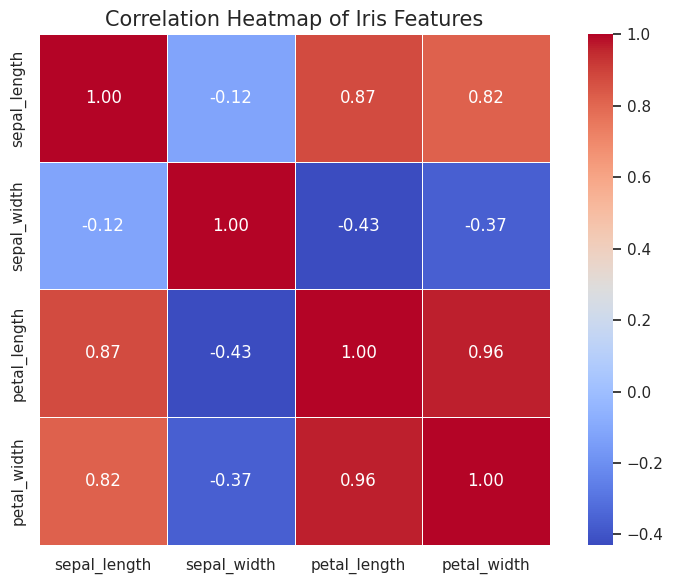

In [11]:
plt.figure(figsize=(8, 6))
corr = iris.drop('species', axis=1).corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', square=True, linewidths=0.5)
plt.title('Correlation Heatmap of Iris Features', fontsize=15)
plt.tight_layout()
plt.show()